In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from dep_tools.grids import PACIFIC_EPSG
from fiona.io import ZipMemoryFile
from odc.geo.geom import Geometry
from odc.geo.xr import mask
from odc.stac import load
from pystac.client import Client
from xarray import DataArray, Dataset

In [2]:
site = "new_georgia_1" 

In [3]:
# aoi = gpd.read_file("priority_1_sites/subsample_sites/"f"{site}.geojson")

In [4]:
aoi = gpd.read_file("potential_sites/"f"{site}.geojson")

In [5]:
bbox = aoi.to_crs("EPSG:4326")

In [6]:
bounds_df = bbox.bounds
bounds_df

,minx,miny,maxx,maxy
0,157.308216,-8.402825,157.744739,-8.060407


In [7]:
values_array = bounds_df.values
flat_array = values_array.flatten()
bbox_int_list = flat_array.tolist()
bbox_tuple = tuple(bbox_int_list)

In [8]:
bbox = Geometry(bbox.geometry.values[0], crs=bbox.crs)

In [9]:
# bbox.explore()

In [10]:
# Get some seagrass data for the area
client = Client.open("https://stac.digitalearthpacific.org")
items = client.search(
    collections=["dep_s2_seagrass"],
    intersects=bbox.json
).item_collection()

print(f"Found {len(items)} items")

Found 32 items


In [11]:
data = load(
    items,
    bbox=bbox_tuple,
    bands=["seagrass"],
    crs=PACIFIC_EPSG,  # 
    resolution=10,  # Change to 10 for full resolution,
    chunks={"x": 2048, "y": 2048}
)

# Convert data to 0 and 1, where 

# data = data.seagrass != 255

data

<xarray.Dataset> Size: 149MB
Dimensions:      (y: 3827, x: 4861, time: 8)
Coordinates:
  * y            (y) float64 31kB -8.943e+05 -8.943e+05 ... -9.325e+05
  * x            (x) float64 39kB 8.135e+05 8.136e+05 ... 8.621e+05 8.621e+05
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01
Data variables:
    seagrass     (time, y, x) uint8 149MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>

In [12]:
import numpy as np
# Access the 'seagrass' data variable specifically
unique_ids = np.unique(data.seagrass.values)
print("Unique Habitat IDs:", unique_ids)

Unique Habitat IDs: [  0   1 255]


In [13]:
# import matplotlib.pyplot as plt

# # 1. SUBSAMPLE: Only plot every 2nd or 4th pixel (e.g., [::2])
# # This reduces the data volume by 4x or 16x without losing the visual pattern
# data_small = data.seagrass.isel(x=slice(0, None, 2), y=slice(0, None, 2))

# # 2. COMPUTE ONCE: Convert to a small numpy array in memory before plotting
# # This prevents the 'lazy' Dask overhead during the plot command
# seagrass_mask = (data_small == 1).compute()

# # 3. PLOT: Use 'mask' to handle transparency (faster than .where(NaN))
# seagrass_mask.plot(
#     col="time",
#     col_wrap=4,
#     levels=[0.5, 1.5], 
#     colors=["#228B22"],
#     cbar_kwargs={"ticks": [1], "label": "Seagrass"}
# )

# plt.gcf().axes[-1].set_yticklabels(['Seagrass'])

[Text(1, 1, 'Seagrass')]

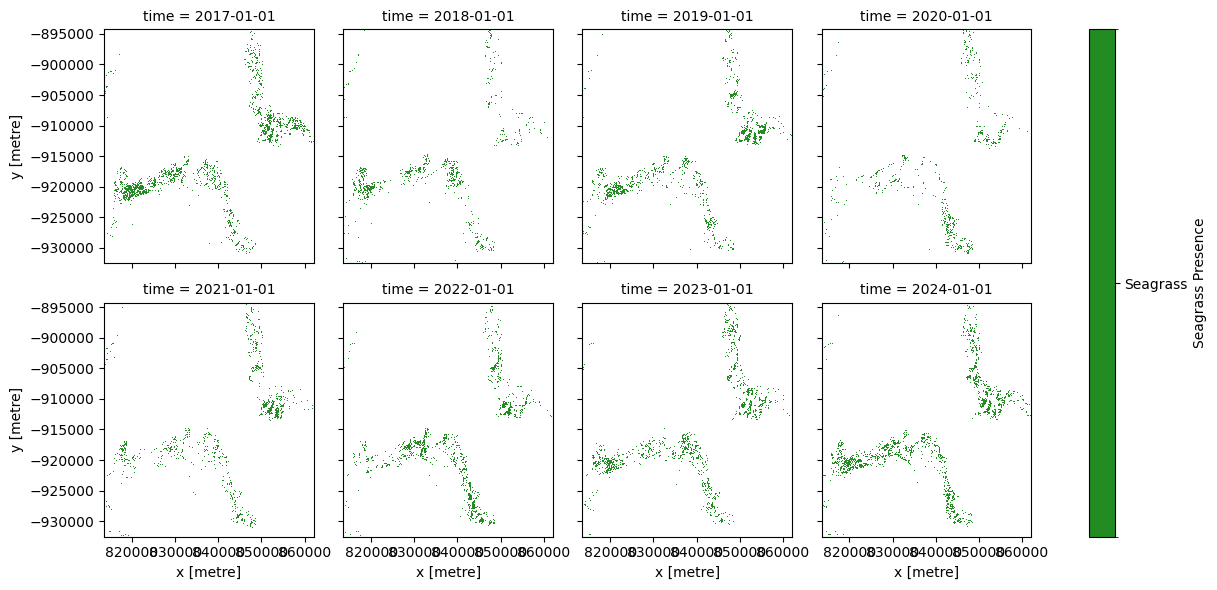

In [14]:
import matplotlib.pyplot as plt

# 1. Filter for Seagrass (ID=1). Everything else becomes NaN (transparent)
seagrass_only = data.seagrass.where(data.seagrass == 1)

# 2. Plot with levels to avoid the ValueError
seagrass_only.plot(
    col="time",
    col_wrap=4,
    # Define a boundary around the value 1
    levels=[0.5, 1.5], 
    # Now that levels is specified, colors will work
    colors=["#228B22"], 
    cbar_kwargs={
        "ticks": [1], 
        "label": "Seagrass Presence"
    }
)

# Optional: Set the colorbar label
plt.gcf().axes[-1].set_yticklabels(['Seagrass'])

In [15]:
print("Unique values in data:", np.unique(data.values))

Unique values in data: [<bound method Mapping.values of <xarray.Dataset> Size: 149MB
 Dimensions:      (y: 3827, x: 4861, time: 8)
 Coordinates:
   * y            (y) float64 31kB -8.943e+05 -8.943e+05 ... -9.325e+05
   * x            (x) float64 39kB 8.135e+05 8.136e+05 ... 8.621e+05 8.621e+05
     spatial_ref  int32 4B 3832
   * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01
 Data variables:
     seagrass     (time, y, x) uint8 149MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>>]


In [16]:
def xarray_calculate_area(
    data: Dataset | DataArray,
    geom: Geometry,
    variable: str | None = None,
    value: int | float | None = None,
) -> float:
    # Work with a dataarray, not a dataset, so it's a singular thing
    if type(data) is not DataArray:
        if variable is None:
            raise ValueError("Variable must be specified when data is a Dataset.")
        data = data[variable]

    # Only select a specific value. This will convert to float, with nans
    if value is not None:
        data = data.where(data == value)

    # Mask out regions outsize the geometry
    masked = mask(data, geom.to_crs(data.odc.crs))

    # Count all the non-nan cells, and multiply by area
    count = float(masked.notnull().sum().values)
    one_pixel_area = abs(
        masked.odc.geobox.resolution.x * masked.odc.geobox.resolution.y
    )

    return float(count) * one_pixel_area

In [17]:
bbox.explore()

In [18]:
data = load(
    items,
    bbox=bbox_tuple,
    bands=["seagrass"],
    crs=PACIFIC_EPSG,  # 
    resolution=10,  # Change to 10 for full resolution,
    chunks={"x": 2048, "y": 2048}
)

# Convert data to 0 and 1, where 

data = data.seagrass != 255

data

<xarray.DataArray 'seagrass' (time: 8, y: 3827, x: 4861)> Size: 149MB
dask.array<ne, shape=(8, 3827, 4861), dtype=bool, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 31kB -8.943e+05 -8.943e+05 ... -9.325e+05
  * x            (x) float64 39kB 8.135e+05 8.136e+05 ... 8.621e+05 8.621e+05
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01

In [19]:
# Run the xarray_calculate_area per time step
results = []
for time in data.time:
    da = data.sel(time=time)
    area_m2 = xarray_calculate_area(da, bbox, variable="seagrass", value=1)
    # Year, in YYYY, area in m2, area in km2
    results.append({
        "time": pd.to_datetime(time.values).year,
        # "area_m2": area_m2,
        "seagrass": area_m2 / 10000
    })

df = pd.DataFrame(results)
# df

In [20]:
# Keep only the rows where year is NOT 2017
df = df[df['time'] != 2017]

# Reset the index so it starts at 0, 1, 2... again
df = df.reset_index(drop=True)

df

,time,seagrass
0,2018,12541.39
1,2019,13367.18
2,2020,14108.39
3,2021,13183.99
4,2022,11286.35
5,2023,11665.14
6,2024,11047.82


<Axes: xlabel='time'>

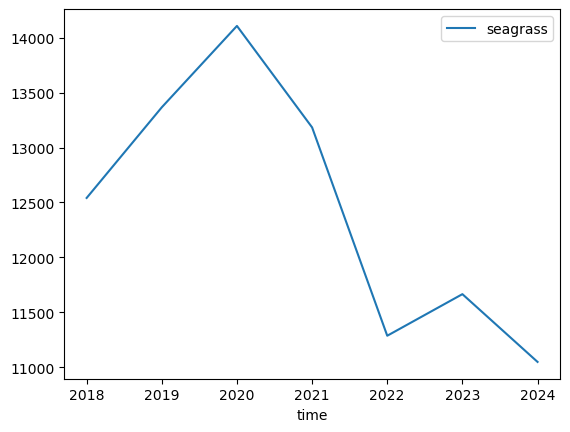

In [21]:
df = df.set_index('time')
df.plot.line()

In [22]:
data

<xarray.DataArray 'seagrass' (time: 8, y: 3827, x: 4861)> Size: 149MB
dask.array<ne, shape=(8, 3827, 4861), dtype=bool, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 31kB -8.943e+05 -8.943e+05 ... -9.325e+05
  * x            (x) float64 39kB 8.135e+05 8.136e+05 ... 8.621e+05 8.621e+05
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01